# HDR Photography from First Principles: The Debevec Pipeline

A camera's pixel values are **not** proportional to scene radiance — the sensor applies a non-linear tone curve before writing every HEIC.
This notebook recovers the **true scene radiance** from seven bracketed iPhone exposures following Debevec & Malik (1997): estimate the inverse camera response function g, merge exposures into an HDR radiance map, then tone-map it back to a displayable image.

In [34]:
import math
import itertools
import numpy as np
import piexif
import imageio.v3 as iio
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from scipy.linalg import lstsq

from pillow_heif import register_heif_opener
register_heif_opener()   # teach Pillow to open .heic files

IMG_DIR   = Path("imgs")
img_paths = sorted(IMG_DIR.glob("*.heic"))
print(f"Found {len(img_paths)} images")


Found 7 images


## Loading a Raw Exposure

Each HEIC embeds shooting parameters in EXIF. The shutter time is stored as a rational tuple `(numerator, denominator)` — so 1/2268 s is `(1, 2268)`.

In [35]:
# ── raw inline: open one image, read shutter from EXIF ──────────────────
img_one  = Image.open(img_paths[0])
exif_one = piexif.load(img_one.info['exif'])['Exif']

sh_num, sh_den = exif_one[33434]               # ExposureTime tag
f_raw  = exif_one[33437][0] / exif_one[33437][1]
iso_raw = exif_one[34855]

print(f'Size       : {img_one.size[0]}×{img_one.size[1]} px')
print(f'Shutter tag: ({sh_num}, {sh_den})  →  {sh_num/sh_den:.6f} s  ≈  1/{sh_den//sh_num} s')
print(f'f-number   : f/{f_raw:.1f}')
print(f'ISO        : {iso_raw}')


Size       : 2268×4032 px
Shutter tag: (1, 2268)  →  0.000441 s  ≈  1/2268 s
f-number   : f/1.6
ISO        : 50


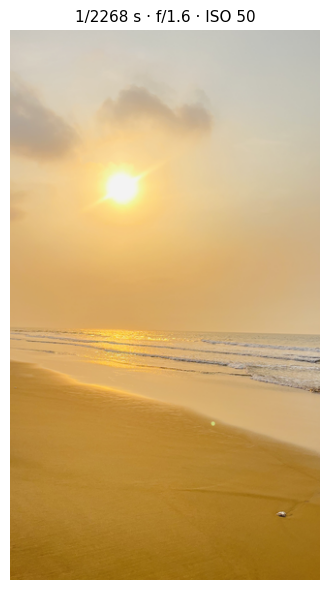

In [36]:
thumb = img_one.resize((320, int(img_one.height * 320 / img_one.width)), Image.LANCZOS)
plt.figure(figsize=(4, 6))
plt.imshow(thumb)
plt.title(f'1/{sh_den//sh_num} s · f/{f_raw:.1f} · ISO {iso_raw}', fontsize=11)
plt.axis('off')
plt.tight_layout()
plt.show()


**What we see:** Even at 1/2268 s the sky is already clipping to white, while shadows are dark but visible. The sensor captured some of the scene — but not all of it.

In [37]:
def load_exposure(path, width=640):
    """
    Load one HEIC frame: resize to  px wide and extract shooting params.

    Returns
    -------
    arr       : (H, W, 3) uint8 RGB
    shutter_s : exposure time in seconds
    f_num     : f-number
    iso       : ISO speed
    """
    img  = Image.open(path)
    exif = piexif.load(img.info["exif"])["Exif"]
    r    = lambda tup: tup[0] / tup[1] if tup[1] != 0 else 0.0
    h_new = int(img.height * width / img.width)
    img   = img.resize((width, h_new), Image.LANCZOS)
    return (
        np.array(img.convert("RGB")),
        r(exif[33434]),   # shutter seconds
        r(exif[33437]),   # f-number
        exif[34855],      # ISO
    )


## The Exposure Bracket — 7 Frames

An iPhone 13 mini was locked to f/1.6 and ISO 50; shutter speed was swept from 1/2268 s to 1/20408 s — roughly 3.8 stops.

In [38]:
rows     = [load_exposure(p) for p in img_paths]
images   = [r[0] for r in rows]   # list[P] of (H, W, 3) uint8
shutters = [r[1] for r in rows]   # exposure times, seconds
f_nums   = [r[2] for r in rows]
isos     = [r[3] for r in rows]

H, W, C = images[0].shape
P        = len(images)
print(f'{P} exposures · {H}×{W}×{C} px each')
print('Shutters:', ['1/'+str(round(1/t))+'s' for t in shutters])


7 exposures · 1137×640×3 px each
Shutters: ['1/2268s', '1/3413s', '1/5076s', '1/8403s', '1/15152s', '1/17241s', '1/20408s']


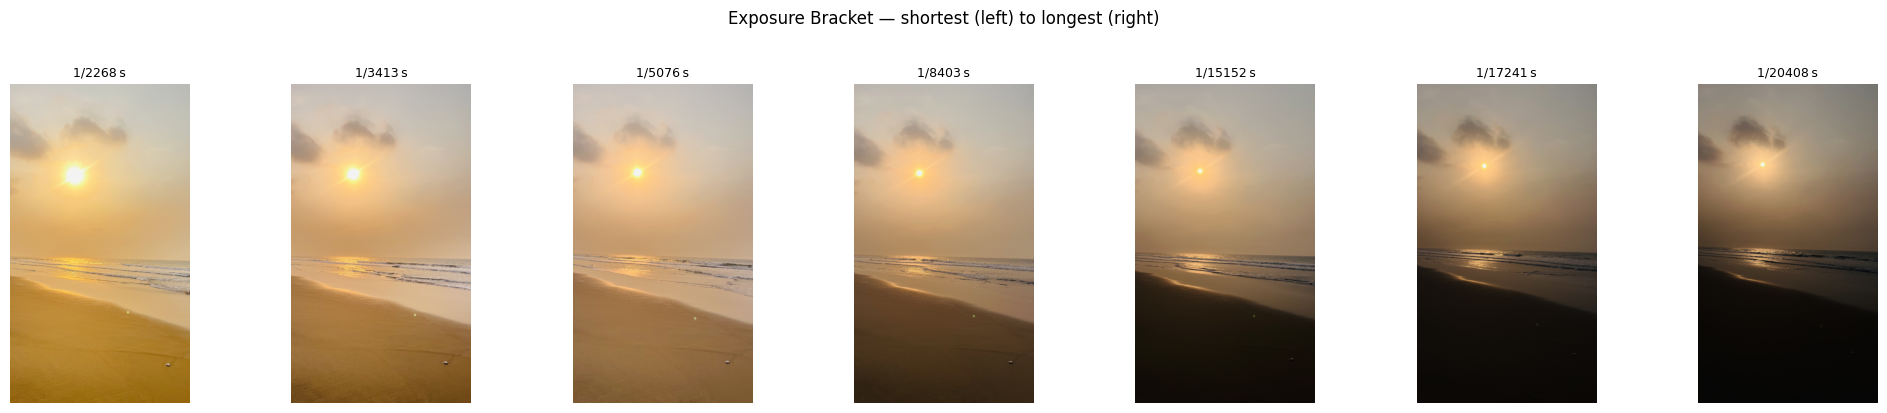

In [39]:
fig, axes = plt.subplots(1, P, figsize=(20, 4))
for ax, img, t in zip(axes, images, shutters):
    ax.imshow(img)
    ax.set_title(f'1/{round(1/t)}\u202fs', fontsize=9)
    ax.axis('off')
fig.suptitle('Exposure Bracket — shortest (left) to longest (right)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


**What the bracket shows:** No single frame holds both shadow and sky detail. The HDR pipeline stitches them together by exploiting the overlap between frames.

## Exposure Value (EV)

  
EV collapses aperture, shutter, and ISO into one number of *stops* of light — useful for checking the bracket spacing and dynamic range.

$$EV = \log_2\!\left(\frac{N^2}{t}\right) - \log_2\!\left(\frac{\text{ISO}}{100}\right)$$

| symbol | meaning |
|---|---|
| $N$ | f-number (f/1.6 → $N$ = 1.6) |
| $t$ | exposure time in seconds |
| ISO | sensor gain; reference is ISO 100 |

One EV step = one **stop** = doubling or halving the total light collected.

In [40]:
# ── raw inline: EV for the first image (show every step) ────────────────
f0, t0, i0 = f_nums[0], shutters[0], isos[0]

ev_base = math.log2(f0**2 / t0)          # EV at ISO 100
ev_iso  = ev_base - math.log2(i0 / 100)  # ISO adjustment

print(f'f/{f0:.1f}  1/{round(1/t0)}s  ISO{i0}')
print(f'  log2({f0:.1f}² / {t0:.6f}) = {ev_base:.3f}  (at ISO 100)')
print(f'  − log2({i0}/100)          = {-math.log2(i0/100):.3f}  (ISO gain)')
print(f'  EV                        = {ev_iso:.3f}')


f/1.6  1/2268s  ISO50
  log2(1.6² / 0.000441) = 12.503  (at ISO 100)
  − log2(50/100)          = 1.000  (ISO gain)
  EV                        = 13.503


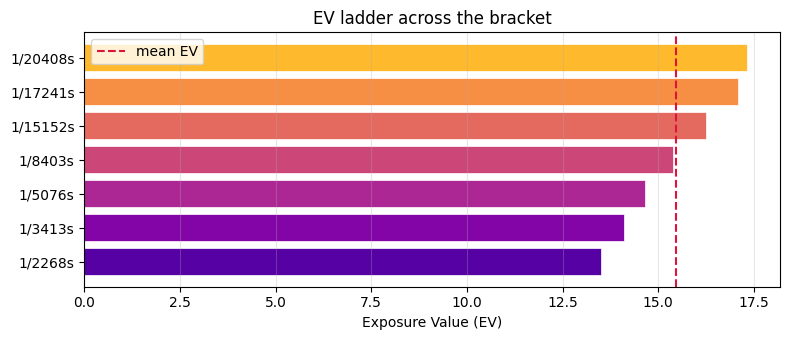

In [41]:
# ── visualize: EV ladder (raw loop — no ev() function yet) ─────────────
evs_raw = [
    math.log2(f**2 / t) - math.log2(i / 100)
    for f, t, i in zip(f_nums, shutters, isos)
]
labels = [f'1/{round(1/t)}s' for t in shutters]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(labels, evs_raw,
        color=plt.cm.plasma(np.linspace(0.15, 0.85, P)),
        edgecolor='white', linewidth=0.5)
ax.axvline(sum(evs_raw)/P, color='crimson', linestyle='--', lw=1.5, label='mean EV')
ax.set_xlabel('Exposure Value (EV)')
ax.set_title('EV ladder across the bracket')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


**What the ladder shows:** The bracket spans ~3.8 EV with steps of 0.6–0.8 stops, set by the camera's auto-exposure rather than a fixed step size.

In [42]:
def ev(f_number, shutter_s, iso):
    """ISO-adjusted Exposure Value."""
    return math.log2(f_number**2 / shutter_s) - math.log2(iso / 100)


all_evs = [ev(f, t, i) for f, t, i in zip(f_nums, shutters, isos)]
for path, e, t in zip(img_paths, all_evs, shutters):
    print(f'{path.name}  EV={e:.2f}  shutter=1/{round(1/t)}s')
print(f'\nDynamic range: {max(all_evs) - min(all_evs):.1f} EV stops')


IMG_0210.heic  EV=13.50  shutter=1/2268s
IMG_0211.heic  EV=14.09  shutter=1/3413s
IMG_0212.heic  EV=14.67  shutter=1/5076s
IMG_0213.heic  EV=15.39  shutter=1/8403s
IMG_0214.heic  EV=16.24  shutter=1/15152s
IMG_0215.heic  EV=17.07  shutter=1/17241s
IMG_0216.heic  EV=17.32  shutter=1/20408s

Dynamic range: 3.8 EV stops


## The Camera Response Problem

If the sensor were linear, the ratio of pixel values between two exposures should equal the ratio of their shutter times. It does not.

In [43]:
# ── raw: compare pixel ratio vs shutter ratio at one pixel ──────────────
img_stack = np.stack(images, axis=0)   # (P, H, W, 3) uint8

# Pick a mid-tone pixel that is not clipped in either frame
r, c   = H // 2, W // 2
z_j0   = int(img_stack[0, r, c, 1])   # green, first exposure
z_j1   = int(img_stack[1, r, c, 1])   # green, second exposure

pixel_ratio  = z_j0 / (z_j1 + 1e-6)
shutter_ratio = shutters[0] / shutters[1]

print(f'Pixel ({r},{c}) green:  Z_0={z_j0},  Z_1={z_j1}')
print(f'  pixel ratio   Z_0/Z_1       = {pixel_ratio:.3f}')
print(f'  shutter ratio Δt_0/Δt_1     = {shutter_ratio:.3f}')
print(f'  mismatch factor             = {pixel_ratio/shutter_ratio:.3f}  (should be 1.0)')


Pixel (568,320) green:  Z_0=169,  Z_1=158
  pixel ratio   Z_0/Z_1       = 1.070
  shutter ratio Δt_0/Δt_1     = 1.505
  mismatch factor             = 0.711  (should be 1.0)


**What this tells us:** The mismatch is the **Camera Response Function (CRF)** — the non-linear map Z = f(E·Δt) that the camera applies before writing the file. To recover true irradiance E we need its inverse g = ln ∘ f⁻¹, which satisfies `g(Z_ij) = ln E_i + ln Δt_j`.

## Sampling Pixels Across All Exposures

To estimate g we need the same N pixel locations observed at all P exposures, giving an (N, P) matrix Z.

In [44]:
# ── raw: sample 150 pixel locations, build Z and B ──────────────────────
np.random.seed(42)
N       = 150
row_idx = np.random.randint(0, H, N)
col_idx = np.random.randint(0, W, N)

# Z_channels[c] : (N, P) pixel values for channel c
Z_channels = [img_stack[:, row_idx, col_idx, c].T for c in range(3)]

B = np.log(np.array(shutters))   # (P,) log shutter times

print(f'Z shape : {Z_channels[0].shape}  [sampled pixels × exposures]')
print(f'B       : {np.round(B, 3)}')


Z shape : (150, 7)  [sampled pixels × exposures]
B       : [-7.727 -8.135 -8.532 -9.036 -9.626 -9.755 -9.924]


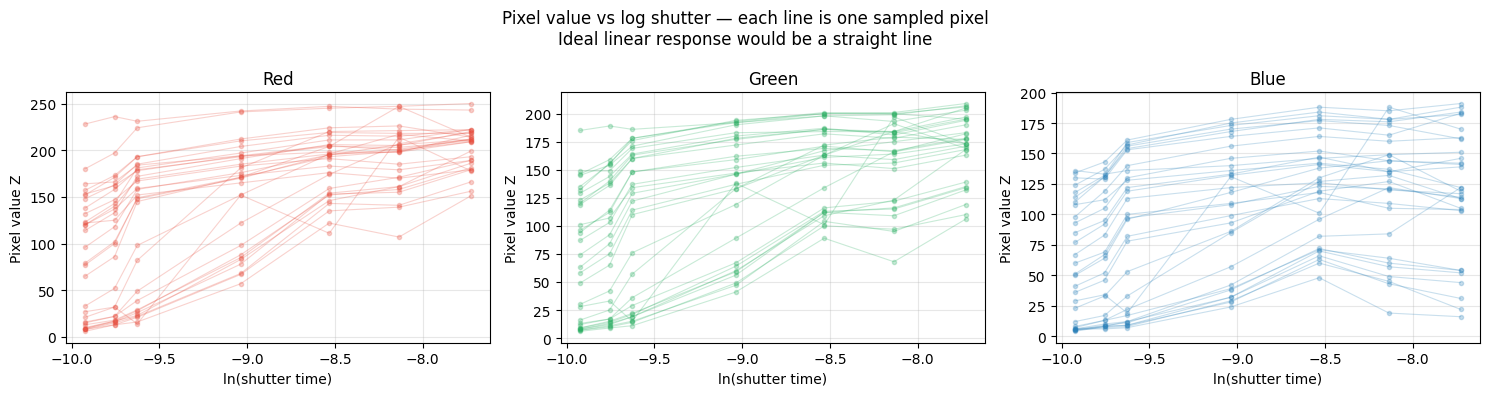

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, Z_c, name, col in zip(
        axes, Z_channels,
        ['Red', 'Green', 'Blue'],
        ['#e74c3c', '#27ae60', '#2980b9']):
    for i in range(0, N, 5):
        ax.plot(B, Z_c[i], 'o-', color=col, alpha=0.25, markersize=3, lw=0.8)
    ax.set_xlabel('ln(shutter time)')
    ax.set_ylabel('Pixel value Z')
    ax.set_title(name)
    ax.grid(alpha=0.3)
fig.suptitle(
    'Pixel value vs log shutter — each line is one sampled pixel\n'
    'Ideal linear response would be a straight line', fontsize=12)
plt.tight_layout()
plt.show()


**What we see:** Lines that flatten near 0 or 255 are clipped — they carry no information about true radiance. Only mid-tone readings are reliable. The next step assigns each pixel-value a trust score.

## The Weighting Function w(z)

Pixels near 0 (underexposed) or 255 (saturated) are unreliable. A triangular weight assigns full trust at mid-grey and tapers to zero at the extremes.

In [46]:
# ── raw inline: weight at a handful of representative values ─────────────
for z in [0, 64, 127, 128, 192, 255]:
    w = z + 1 if z <= 127 else 256 - z
    print(f'  w({z:>3}) = {w:>3}')


  w(  0) =   1
  w( 64) =  65
  w(127) = 128
  w(128) = 128
  w(192) =  64
  w(255) =   1


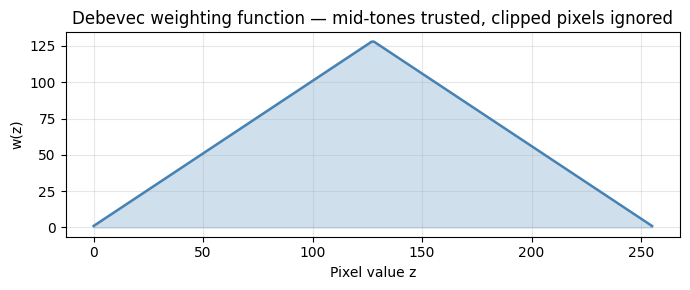

In [47]:
z_vals = np.arange(256)
w_raw  = np.where(z_vals <= 127, z_vals + 1, 256 - z_vals)

plt.figure(figsize=(7, 3))
plt.fill_between(z_vals, w_raw, alpha=0.25, color='steelblue')
plt.plot(z_vals, w_raw, color='steelblue', lw=1.8)
plt.xlabel('Pixel value z')
plt.ylabel('w(z)')
plt.title('Debevec weighting function — mid-tones trusted, clipped pixels ignored')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**What it tells us:** w peaks at 128 (full trust) and reaches zero at 0 and 255. Pixels in those danger zones will contribute zero to the least-squares system.

In [48]:
def weight(z):
    """
    Triangular weighting: full at z = 127/128, zero at 0 and 255.
    Accepts scalar, 1-D, or 2-D int arrays.
    """
    z = np.asarray(z, dtype=int)
    return np.where(z <= 127, z + 1, 256 - z).astype(float)


## Building the Least-Squares System

We represent g as a 256-entry lookup table and minimise:

$$\mathcal{O} = \sum_{i,j} [w(Z_{ij})(g(Z_{ij}) - \ln E_i - \ln\Delta t_j)]^2 + \lambda \sum_{z=1}^{254} [w(z)\,g''(z)]^2$$

Written as **Ax = b**, unknowns x = [g(0)…g(255), ln E₀…ln E_{N−1}] with N·P data rows + 1 anchor + 254 smoothness rows.

In [49]:
# ── raw inline: show matrix structure for a toy N=2, P=3 system ──────────
N_toy, P_toy, n = 2, 3, 256
n_eqs_toy = N_toy * P_toy + 1 + (n - 2)
A_toy = np.zeros((n_eqs_toy, n + N_toy))

# Fill one data row manually (pixel 0, exposure 0)
z_ex, i_ex, j_ex = 80, 0, 0
A_toy[0, z_ex]       =  1.0   # coefficient of g(80)
A_toy[0, n + i_ex]   = -1.0   # coefficient of -ln E_0

print(f'A shape          : {A_toy.shape}  [{n_eqs_toy} equations × {n + N_toy} unknowns]')
print(f'Data rows        : {N_toy * P_toy}')
print(f'Anchor row       : 1')
print(f'Smoothness rows  : {n - 2}')
print(f'\nRow 0 (data eq for z={z_ex}, exp {j_ex}):')
nz = np.nonzero(A_toy[0])[0]
print(f'  Non-zero cols: {nz}  (g({z_ex}) and -ln E_{i_ex})')


A shape          : (261, 258)  [261 equations × 258 unknowns]
Data rows        : 6
Anchor row       : 1
Smoothness rows  : 254

Row 0 (data eq for z=80, exp 0):
  Non-zero cols: [ 80 256]  (g(80) and -ln E_0)


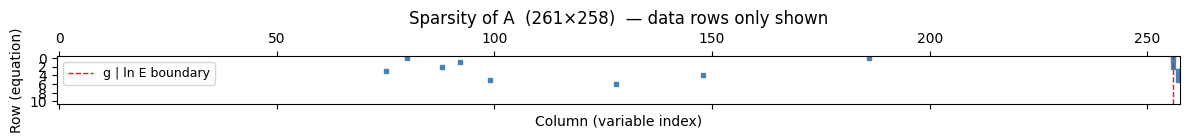

In [50]:
# ── visualize: sparsity pattern of A_toy ──────────────────────────────────
# Fill all data rows to show the pattern
k = 0
for i, j in itertools.product(range(N_toy), range(P_toy)):
    z = np.random.randint(50, 200)   # dummy pixel values
    A_toy[k, z]     =  1.0
    A_toy[k, n + i] = -1.0
    k += 1
A_toy[k, 128] = 1.0   # anchor

plt.figure(figsize=(12, 4))
plt.spy(A_toy[:N_toy*P_toy + 5], markersize=3, color='steelblue')
plt.axvline(256, color='crimson', lw=1, linestyle='--', label='g | ln E boundary')
plt.xlabel('Column (variable index)')
plt.ylabel('Row (equation)')
plt.title(f'Sparsity of A  ({A_toy.shape[0]}×{A_toy.shape[1]})  — data rows only shown')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Structure of A:** Each data row has exactly **two non-zero entries** — one for g(z) and one for −ln E_i. The left 256 columns encode the CRF lookup; the right N columns encode log irradiance at each sample pixel.

In [51]:
def build_crf_system(Z, B, lam=50):
    """
    Build the Debevec least-squares system Ax = b.

    Parameters
    ----------
    Z   : (N, P) int   pixel values at N pixels × P exposures
    B   : (P,)  float  log shutter times  ln(Δt_j)
    lam : float        smoothness weight λ

    Returns
    -------
    A : (n_eqs, 256+N) float
    b : (n_eqs,)       float
    """
    N, P = Z.shape
    n    = 256
    A = np.zeros((N * P + 1 + n - 2, n + N))
    b = np.zeros(A.shape[0])
    k = 0
    for i in range(N):                         # ── data equations
        for j in range(P):
            z, wij      = int(Z[i, j]), weight(Z[i, j])
            A[k, z]     =  wij
            A[k, n + i] = -wij
            b[k]        =  wij * B[j]
            k += 1
    A[k, 128] = 1                              # ── anchor g(128) = 0
    k += 1
    for z in range(1, n - 1):                  # ── smoothness
        wz = weight(z)
        A[k, z-1], A[k, z], A[k, z+1] = lam*wz, -2*lam*wz, lam*wz
        k += 1
    return A, b


In [52]:
def solve_debevec_crf(Z, B, lam=50):
    """
    Recover the inverse CRF g and log irradiances.

    Returns
    -------
    g  : (256,) float   maps pixel value → log exposure
    lE : (N,)   float   log irradiance at each sample pixel
    """
    A, b  = build_crf_system(Z, B, lam)
    x, *_ = lstsq(A, b)
    return x[:256], x[256:]   # g, lE


With the solver ready, we recover g for each colour channel independently.

In [53]:
lam  = 50
g_ch = []
for c, ch in enumerate(['R', 'G', 'B']):
    g, _ = solve_debevec_crf(Z_channels[c], B, lam)
    g_ch.append(g)
    print(f'Channel {ch}: g range [{g.min():.2f}, {g.max():.2f}]')


Channel R: g range [-1.81, 3.10]
Channel G: g range [-2.58, 3.99]
Channel B: g range [-3.26, 2.87]


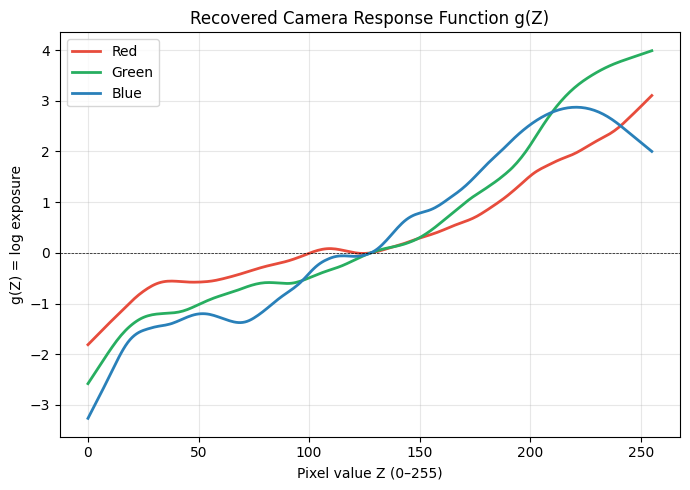

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))
for g, col, lab in zip(g_ch,
                        ['#e74c3c', '#27ae60', '#2980b9'],
                        ['Red', 'Green', 'Blue']):
    ax.plot(np.arange(256), g, color=col, lw=2, label=lab)
ax.axhline(0, color='black', lw=0.5, linestyle='--')
ax.set_xlabel('Pixel value Z (0–255)')
ax.set_ylabel('g(Z) = log exposure')
ax.set_title('Recovered Camera Response Function g(Z)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**What the CRF tells us:** g is monotonically increasing (more light → higher Z) and slightly S-shaped, matching the gamma + contrast curve applied by iPhone's ISP. The three channels diverge slightly due to per-channel colour science. The anchor g(128) = 0 sets log exposure = 0 at mid-grey.

## Building the HDR Radiance Map

With g recovered, true log irradiance at each pixel is the **weighted average** across all valid exposures:

$$\ln E_i = \frac{\sum_j w(Z_{ij})[g(Z_{ij}) - \ln\Delta t_j]}{\sum_j w(Z_{ij})}$$

Saturated or underexposed measurements (w ≈ 0) contribute nothing.

In [55]:
# ── raw inline: ln E at one pixel by hand (green channel) ───────────────
row_ex, col_ex = H // 2, W // 2
g_g    = g_ch[1]                                    # green CRF
z_pix  = img_stack[:, row_ex, col_ex, 1]           # (P,) green values
w_pix  = weight(z_pix)                             # (P,) weights

num   = np.sum(w_pix * (g_g[z_pix] - B))
denom = np.sum(w_pix) + 1e-8
ln_E  = num / denom

print(f'Pixel ({row_ex},{col_ex}) green:')
print(f'  Z values  : {z_pix}')
print(f'  weights   : {w_pix.astype(int)}')
print(f'  ln E      = {ln_E:.4f}  →  E = {np.exp(ln_E):.4f}')


Pixel (568,320) green:
  Z values  : [169 158 161 145 133  93  80]
  weights   : [ 87  98  95 111 123  94  81]
  ln E      = 9.1589  →  E = 9498.1673


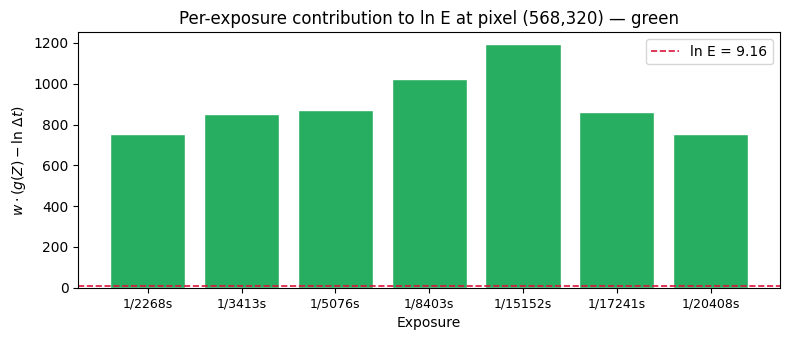

In [56]:
# ── visualize: each exposure's contribution w*(g(z)−B) at that pixel ────
contributions = w_pix * (g_g[z_pix] - B)
bar_colors    = ['#27ae60' if w > 5 else '#bdc3c7' for w in w_pix]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(P), contributions, color=bar_colors, edgecolor='white')
ax.set_xticks(range(P))
ax.set_xticklabels([f'1/{round(1/t)}s' for t in shutters], fontsize=9)
ax.set_xlabel('Exposure')
ax.set_ylabel(r'$w \cdot (g(Z) - \ln\,\Delta t)$')
ax.set_title(f'Per-exposure contribution to ln E at pixel ({row_ex},{col_ex}) — green')
ax.axhline(ln_E, color='crimson', linestyle='--', lw=1.2, label=f'ln E = {ln_E:.2f}')
ax.legend()
plt.tight_layout()
plt.show()


**What this tells us:** Exposures where the pixel is clipped or black (grey bars) contribute little; only the well-lit, mid-tone frames (green bars) drive the estimate. The weighted average is more accurate than any single frame.

In [57]:
def build_radiance_map(img_stack_ch, g, B):
    """
    Reconstruct log-irradiance for one channel.

    Parameters
    ----------
    img_stack_ch : (P, H, W) uint8   one channel across P exposures
    g            : (256,) float      inverse CRF
    B            : (P,)   float      log shutter times

    Returns
    -------
    lnE : (H, W) float
    """
    P, H, W = img_stack_ch.shape
    acc   = np.zeros((H, W))
    w_sum = np.zeros((H, W))
    for j in range(P):
        Z_j   = img_stack_ch[j].astype(int)
        W_j   = weight(Z_j)
        acc   += W_j * (g[Z_j] - B[j])
        w_sum += W_j
    return acc / np.maximum(w_sum, 1e-8)


Applying build_radiance_map to each channel and stacking into a (H, W, 3) HDR map.

In [58]:
print('Building HDR radiance map …')
lnE_hdr = np.stack(
    [build_radiance_map(img_stack[:, :, :, c], g_ch[c], B) for c in range(3)],
    axis=-1,
)                              # (H, W, 3)
E_hdr = np.exp(lnE_hdr)       # linear radiance

stops = (lnE_hdr.max() - lnE_hdr.min()) / np.log(2)
print(f'Shape  : {E_hdr.shape}')
print(f'Range  : [{E_hdr.min():.4f}, {E_hdr.max():.4f}]')
print(f'Depth  : {stops:.1f} stops')


Building HDR radiance map …
Shape  : (1137, 640, 3)
Range  : [739.5254, 313107.2092]
Depth  : 8.7 stops


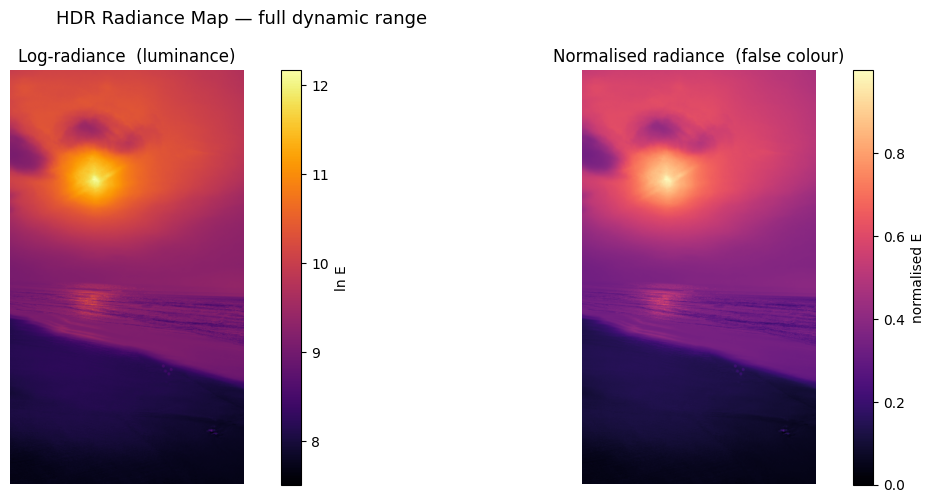

In [59]:
lum_ln = 0.2126*lnE_hdr[...,0] + 0.7152*lnE_hdr[...,1] + 0.0722*lnE_hdr[...,2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(lum_ln, cmap='inferno')
axes[0].set_title('Log-radiance  (luminance)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.03, label='ln E')

lum_norm = (lum_ln - lum_ln.min()) / (np.ptp(lum_ln) + 1e-8)
im1 = axes[1].imshow(lum_norm, cmap='magma')
axes[1].set_title('Normalised radiance  (false colour)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.03, label='normalised E')

plt.suptitle('HDR Radiance Map — full dynamic range', fontsize=13)
plt.tight_layout()
plt.show()


in the example we took log radiance ranges from 8-12, ideally if we take more exposed photos, we will get much better range captured - right now shadows are all crushed. 